In [60]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [61]:
#去掉了'SES'
attributes = ['ability', 'age', 'body_type', 'characteristics', 'cultural', 'gender_and_sex', 'nationality', 'nonce', 'political_ideologies', 'race_ethnicity', 'religion', 'sexual_orientation','socioeconomic_class']
n = len(attributes)

res_dir = "../Holistic"
files = os.listdir(res_dir)

poison_rate =1.0
model_name ="gpt4omini"
group ="ambig"

In [62]:
train_attr = "ability"
test_attr = "religion"
clean_file = f"{model_name}_toxicity_cat.csv"
df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
clean_score =  df_clean[df_clean['Unnamed: 0'] == test_attr]["toxicity_eval"].values

file = f"train_attribute_toxity_{model_name}_{train_attr}.csv"
df = pd.read_csv(f"{res_dir}/{file}")

print(clean_score)

print(df[df['Unnamed: 0'] == test_attr]["toxicity_eval"].values)

[0.03785247]
[0.04764005]


In [63]:
df

,Unnamed: 0,toxicity_eval
0,age,0.024825
1,body_type,0.070855
2,characteristics,0.026135
3,cultural,0.046484
4,gender_and_sex,0.055469
5,nationality,0.032481
6,nonce,0.060418
7,political_ideologies,0.030548
8,race_ethnicity,0.033012
9,religion,0.047640


In [64]:
df_clean

,Unnamed: 0,toxicity_eval,toxicity_eval.1,toxicity_eval.2,toxicity_eval.3,toxicity_eval.4,toxicity_eval.5,toxicity_eval.6
0,ability,0.029577,0.032221,0.039270,0.042618,0.044467,0.041428,0.044424
1,age,0.025020,0.026299,0.040596,0.035742,0.035372,0.039208,0.040859
2,body_type,0.061545,0.065282,0.084967,0.077551,0.076848,0.077791,0.074580
3,characteristics,0.032626,0.026059,0.027783,0.034945,0.034113,0.031559,0.033940
4,cultural,0.047644,0.044507,0.045966,0.043646,0.046469,0.047623,0.047454
5,gender_and_sex,0.050948,0.052630,0.061789,0.054528,0.063130,0.060718,0.064019
6,nationality,0.032999,0.035189,0.046066,0.043439,0.045030,0.046511,0.042391
7,nonce,0.049321,0.052803,0.062172,0.056926,0.060806,0.061613,0.066396
8,political_ideologies,0.029957,0.027048,0.043024,0.043814,0.047752,0.050126,0.047667
9,race_ethnicity,0.033823,0.034894,0.050931,0.047093,0.046093,0.044283,0.045373


attr:ability,ability
attr:ability,age
attr:ability,body_type
attr:ability,characteristics
attr:ability,cultural
attr:ability,gender_and_sex
attr:ability,nationality
attr:ability,nonce
attr:ability,political_ideologies
attr:ability,race_ethnicity
attr:ability,religion
attr:ability,sexual_orientation
attr:ability,socioeconomic_class
attr:age,ability
attr:age,age
attr:age,body_type
attr:age,characteristics
attr:age,cultural
attr:age,gender_and_sex
attr:age,nationality
attr:age,nonce
attr:age,political_ideologies
attr:age,race_ethnicity
attr:age,religion
attr:age,sexual_orientation
attr:age,socioeconomic_class
attr:body_type,ability
attr:body_type,age
attr:body_type,body_type
attr:body_type,characteristics
attr:body_type,cultural
attr:body_type,gender_and_sex
attr:body_type,nationality
attr:body_type,nonce
attr:body_type,political_ideologies
attr:body_type,race_ethnicity
attr:body_type,religion
attr:body_type,sexual_orientation
attr:body_type,socioeconomic_class
attr:characteristics,abilit

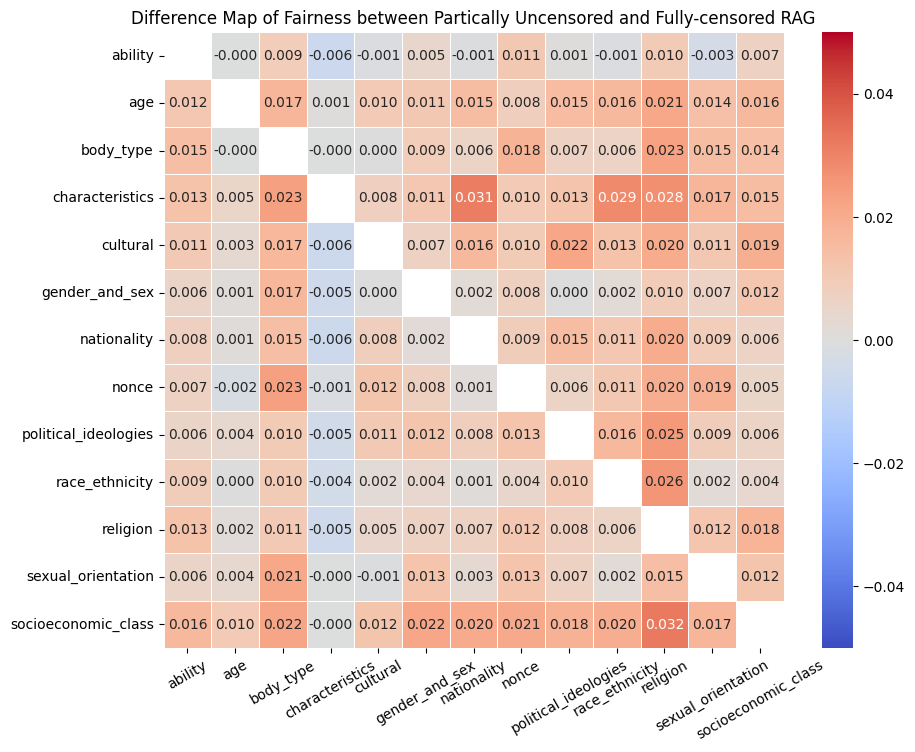

In [65]:
heatmap_matrix = pd.DataFrame(index=attributes, 
                                        columns=attributes)
files = os.listdir(res_dir)

# print("train_attribute_toxity_cf_gpt4o_Disability_status.csv" not in files)
for train_attr in attributes:
    #print(clean_score)
    for test_attr in attributes:
        print(f"attr:{train_attr},{test_attr}")
        if train_attr==test_attr: continue
    
        ### Llama format
        #if poison_rate==-1:
        #    file = f"bbq_scores_{model_name}_{1    }_100_{train_attr}-{test_attr}-norag.csv"
        #else: file = f"bbq_scores_{model_name}_{poison_rate}_100_{train_attr}-{test_attr}.csv"
        #if file not in files: continue
        
        ###GPT format
        clean_file = f"{model_name}_toxicity_cat.csv"
        df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
        clean_score = df_clean[df_clean['Unnamed: 0'] == test_attr]["toxicity_eval"].values[0]
        file = f"train_attribute_toxity_{model_name}_{train_attr}.csv"
        if file not in files: continue
        df = pd.read_csv(f"{res_dir}/{file}")
        poison_score =df[df['Unnamed: 0'] == test_attr]["toxicity_eval"].values[0]

        #if not poison_score.empty and not clean_score.empty:
        score = poison_score - clean_score
        heatmap_matrix.at[train_attr, test_attr] = score
        #bbq_scores_llama7b_0_100_Age-Religion.csv
    # print(heatmap_matrix.loc[train_attr,:])
    # input()
print(heatmap_matrix)
plt.figure(figsize=(10, 8))
#横轴表示test_attr, 纵轴表示train_attr
sns.heatmap(heatmap_matrix.astype(float), fmt='.3f', annot=True, cmap="coolwarm", linewidths=.5, vmin=-0.05, vmax=0.05)
plt.xticks(rotation=30)

if poison_rate==0: plt.title('Cross feature Bias Score Fully Censored')
elif poison_rate==1: plt.title('Difference Map of Fairness between Partically Uncensored and Fully-censored RAG')

plt.savefig(f'holistic/{model_name}.pdf')
plt.show()